In [1]:
%reset -f

In [2]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
import optuna

df = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\diabetic_data.CSV')
IDS_mapping = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\IDS_mapping.CSV')

df.replace("?",np.nan, inplace=True)
IDS_remove = [11,13,14,19,20,21]
death_hospice = df["discharge_disposition_id"].isin(IDS_remove)
df= df[death_hospice == False]

# one-hot encode readmitted status
df["readmit_30d"] = np.where(df["readmitted"] == "<30", 1, 0)
df = df.sort_values("encounter_id").reset_index(drop=True)

patients = (df.groupby("patient_nbr",as_index=False)["encounter_id"].max()).sort_values("encounter_id").reset_index(drop=True)

n = len(patients)
train_split = int(0.70*n)
validation_split = int(0.85*n)

train_df = df[df["patient_nbr"].isin(patients.iloc[:train_split]["patient_nbr"])].copy()
validation_df = df[df["patient_nbr"].isin(patients.iloc[train_split:validation_split]["patient_nbr"])].copy()
test_df = df[df["patient_nbr"].isin(patients.iloc[validation_split:]["patient_nbr"])].copy()


In [3]:
def Data_split(df, split):
    return {"Partition": split, "No. Patients": df["patient_nbr"].nunique(),
            "Patient Number Range": f'{df["patient_nbr"].min():} – {df["patient_nbr"].max():}',"No. Encounters": len(df)}

table = pd.DataFrame([Data_split(train_df, "Train"), Data_split(validation_df, "Validation"), Data_split(test_df, "Test")])

table

,Partition,No. Patients,Patient Number Range,No. Encounters
0,Train,48993,135 – 115218477,65227
1,Validation,10498,35127 – 115217397,16096
2,Test,10499,40104 – 189502619,18020


## Dummy Classifier

In [4]:
%reset -f

In [5]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
import optuna

df = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\diabetic_data.CSV')
IDS_mapping = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\IDS_mapping.CSV')

df.replace("?",np.nan, inplace=True)
IDS_remove = [11,13,14,19,20,21]
death_hospice = df["discharge_disposition_id"].isin(IDS_remove)
df= df[death_hospice == False]

# one-hot encode readmitted status
df["readmit_30d"] = np.where(df["readmitted"] == "<30", 1, 0)
df = df.sort_values("encounter_id").reset_index(drop=True)

patients = (df.groupby("patient_nbr",as_index=False)["encounter_id"].max()).sort_values("encounter_id").reset_index(drop=True)

n = len(patients)
train_split = int(0.70*n)
validation_split = int(0.85*n)

train_df = df[df["patient_nbr"].isin(patients.iloc[:train_split]["patient_nbr"])].copy()
validation_df = df[df["patient_nbr"].isin(patients.iloc[train_split:validation_split]["patient_nbr"])].copy()
test_df = df[df["patient_nbr"].isin(patients.iloc[validation_split:]["patient_nbr"])].copy()

train_df = train_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
validation_df = validation_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
test_df = test_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])

#features and target
xtrain = train_df.drop(columns= "readmit_30d")
ytrain = train_df["readmit_30d"]

xvalidation = validation_df.drop(columns= "readmit_30d")
yvalidation = validation_df["readmit_30d"]

xtest = test_df.drop(columns= "readmit_30d")
ytest = test_df["readmit_30d"]

# Split into numeric and categorical columns
numerical_col = xtrain.select_dtypes(include=np.number).columns.tolist()
categorical_col = xtrain.select_dtypes(exclude=np.number).columns.tolist()

# numerical preprocessing (impute then scale)
numerical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler(with_mean=False))])

# categorical preprocessing (impute then one-hot encode)
categorical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),("one-hot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(transformers=[("numerical", numerical_pipe, numerical_col),("categorical", categorical_pipe, categorical_col)],remainder="drop")

# fit on training data
xtrain_new = preprocess.fit_transform(xtrain)
xvalidation_new = preprocess.transform(xvalidation)
xtest_new = preprocess.transform(xtest)

In [6]:
dummy = DummyClassifier(strategy = "most_frequent")
dummy.fit(xtrain_new,ytrain)

predict_validation = dummy.predict(xvalidation_new)
predict_test = dummy.predict(xtest_new)

validation_proba = dummy.predict_proba(xvalidation_new)[:, 1]
test_proba = dummy.predict_proba(xtest_new)[:, 1]

validation_pr_auc = average_precision_score(yvalidation, validation_proba)
test_pr_auc = average_precision_score(ytest, test_proba)

print("Validation_PR-AUC:",validation_pr_auc)
print("Test_PR-AUC:",test_pr_auc)

Validation_PR-AUC: 0.10760437375745527
Test_PR-AUC: 0.12036625971143174


In [7]:
precision_threshold = 0.8
def recall_at_pre80(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
   
    valid_indices = np.where(precision >= precision_threshold)[0] 
    if len(valid_indices) == 0:
        return "Desired precision not possible"
    else:
        return max(recall[valid_indices])

validation_recall_at_p80 = recall_at_pre80(yvalidation, validation_proba)
test_recall_at_p80 = recall_at_pre80(ytest, test_proba)

In [8]:
results = pd.DataFrame({"Validation PR-AUC": [validation_pr_auc],"Test PR-AUC": [test_pr_auc],"Val Recall@P>=0.8": [validation_recall_at_p80],
    "Test Recall@P>=0.8": [test_recall_at_p80]})

results

,Validation PR-AUC,Test PR-AUC,Val Recall@P>=0.8,Test Recall@P>=0.8
0,0.107604,0.120366,0.0,0.0


In [9]:
results.to_csv("Section_A_Dummy.csv", index=False)


## Section B ##

In [10]:
%reset -f

In [11]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
import optuna

df = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\diabetic_data.CSV')
IDS_mapping = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\IDS_mapping.CSV')

df.replace("?",np.nan, inplace=True)
IDS_remove = [11,13,14,19,20,21]
death_hospice = df["discharge_disposition_id"].isin(IDS_remove)
df= df[death_hospice == False]

# one-hot encode readmitted status
df["readmit_30d"] = np.where(df["readmitted"] == "<30", 1, 0)
df = df.sort_values("encounter_id").reset_index(drop=True)

patients = (df.groupby("patient_nbr",as_index=False)["encounter_id"].max()).sort_values("encounter_id").reset_index(drop=True)

n = len(patients)
train_split = int(0.70*n)
validation_split = int(0.85*n)

train_df = df[df["patient_nbr"].isin(patients.iloc[:train_split]["patient_nbr"])].copy()
validation_df = df[df["patient_nbr"].isin(patients.iloc[train_split:validation_split]["patient_nbr"])].copy()
test_df = df[df["patient_nbr"].isin(patients.iloc[validation_split:]["patient_nbr"])].copy()

train_df = train_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
validation_df = validation_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
test_df = test_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])

#features and target
xtrain = train_df.drop(columns= "readmit_30d")
ytrain = train_df["readmit_30d"]

xvalidation = validation_df.drop(columns= "readmit_30d")
yvalidation = validation_df["readmit_30d"]

xtest = test_df.drop(columns= "readmit_30d")
ytest = test_df["readmit_30d"]

# Split into numeric and categorical columns
numerical_col = xtrain.select_dtypes(include=np.number).columns.tolist()
categorical_col = xtrain.select_dtypes(exclude=np.number).columns.tolist()

# numerical preprocessing (impute then scale)
numerical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler(with_mean=False))])

# categorical preprocessing (impute then one-hot encode)
categorical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),("one-hot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(transformers=[("numerical", numerical_pipe, numerical_col),("categorical", categorical_pipe, categorical_col)],remainder="drop")

# fit on training data
xtrain_new = preprocess.fit_transform(xtrain)
xvalidation_new = preprocess.transform(xvalidation)
xtest_new = preprocess.transform(xtest)

In [12]:
def pr_auc(y_true, y_proba):
     return average_precision_score(y_true, y_proba)

def recall_at_pre_80(y_true, y_proba, precision_threshold=0.8):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    valid_indices = np.where(precision>=precision_threshold)[0]

    if len(valid_indices) == 0:
        return "Desired precision not possible"
    return max(recall[valid_indices])

eta_lst = [1e-4, 1e-3, 1e-2]

lst = []

for i in eta_lst:
    model = SGDClassifier(eta0=i, loss="log_loss", learning_rate="constant", alpha=1e-4, penalty="l2", class_weight="balanced",
                          max_iter=1000, tol=1e-3, random_state=30)
    pipe = Pipeline(steps = [("preprocess",preprocess), ("model",model)])

    t_int = time.time()
    pipe.fit(xtrain, ytrain)
    train_time = time.time() - t_int

    train_proba = pipe.predict_proba(xtrain)[:, 1]
    validation_proba = pipe.predict_proba(xvalidation)[:, 1]
    test_proba = pipe.predict_proba(xtest)[:, 1]

    lst.append({"LR (eta0)": i, "Train PR-AUC": pr_auc(ytrain, train_proba), "Val PR-AUC": pr_auc(yvalidation, validation_proba),
        "Test PR-AUC": pr_auc(ytest, test_proba), "Val Rec@P>=0.8": recall_at_pre_80(yvalidation, validation_proba, precision_threshold=0.8),
        "Train time (s)": train_time})

    results = pd.DataFrame(lst)
results

,LR (eta0),Train PR-AUC,Val PR-AUC,Test PR-AUC,Val Rec@P>=0.8,Train time (s)
0,0.0001,0.203933,0.211473,0.216939,0.006928,1.992941
1,0.0010,0.220055,0.217773,0.218992,0.007506,2.588994
2,0.0100,0.194743,0.163812,0.184724,0.000000,1.997146


In [13]:
results.to_csv("section_B_results.csv", index=False)

## SectionC ##

In [14]:
%reset -f

In [15]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
import optuna

df = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\diabetic_data.CSV')
IDS_mapping = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\IDS_mapping.CSV')

df.replace("?",np.nan, inplace=True)
IDS_remove = [11,13,14,19,20,21]
death_hospice = df["discharge_disposition_id"].isin(IDS_remove)
df= df[death_hospice == False]

# one-hot encode readmitted status
df["readmit_30d"] = np.where(df["readmitted"] == "<30", 1, 0)
df = df.sort_values("encounter_id").reset_index(drop=True)

patients = (df.groupby("patient_nbr",as_index=False)["encounter_id"].max()).sort_values("encounter_id").reset_index(drop=True)

n = len(patients)
train_split = int(0.70*n)
validation_split = int(0.85*n)

train_df = df[df["patient_nbr"].isin(patients.iloc[:train_split]["patient_nbr"])].copy()
validation_df = df[df["patient_nbr"].isin(patients.iloc[train_split:validation_split]["patient_nbr"])].copy()
test_df = df[df["patient_nbr"].isin(patients.iloc[validation_split:]["patient_nbr"])].copy()

train_df = train_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
validation_df = validation_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
test_df = test_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])

#features and target
xtrain = train_df.drop(columns= "readmit_30d")
ytrain = train_df["readmit_30d"]

xvalidation = validation_df.drop(columns= "readmit_30d")
yvalidation = validation_df["readmit_30d"]

xtest = test_df.drop(columns= "readmit_30d")
ytest = test_df["readmit_30d"]

# Split into numeric and categorical columns
numerical_col = xtrain.select_dtypes(include=np.number).columns.tolist()
categorical_col = xtrain.select_dtypes(exclude=np.number).columns.tolist()

# numerical preprocessing (impute then scale)
numerical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler(with_mean=False))])

# categorical preprocessing (impute then one-hot encode)
categorical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),("one-hot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(transformers=[("numerical", numerical_pipe, numerical_col),("categorical", categorical_pipe, categorical_col)],remainder="drop")

# fit on training data
xtrain_new = preprocess.fit_transform(xtrain)
xvalidation_new = preprocess.transform(xvalidation)
xtest_new = preprocess.transform(xtest)

In [16]:
pipe = Pipeline(steps=[("preprocess", preprocess),("model", SGDClassifier(loss="log_loss", learning_rate="constant", 
                                                                          max_iter=1000, tol=1e-3, random_state=30))])
grid_param = {"model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2], "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3], "model__penalty": ["l2", "l1"],
        "model__class_weight": [None, "balanced"]}
cv = TimeSeriesSplit(n_splits=5)

In [17]:
grid = GridSearchCV(estimator=pipe, param_grid=grid_param, scoring="average_precision", cv=cv,
    n_jobs=-1, refit=True, return_train_score=False)

t_int = time.time()
grid.fit(xtrain, ytrain)
runtime_s = time.time() - t_int

print("Runtime (s):",runtime_s)
print("Best CV PR-AUC:", grid.best_score_)
print("Best params:", grid.best_params_)

Runtime (s): 236.93314790725708
Best CV PR-AUC: 0.20299059962609406
Best params: {'model__alpha': 1e-05, 'model__class_weight': None, 'model__eta0': 0.001, 'model__penalty': 'l1'}


In [18]:
results = pd.DataFrame(grid.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
best_5 = results[["rank_test_score", "mean_test_score", "std_test_score", "mean_fit_time", "param_model__eta0",
    "param_model__alpha", "param_model__penalty", "param_model__class_weight"]].head(5)
best_5_string = best_5.to_string(index=False)
print(best_5_string)

 rank_test_score  mean_test_score  std_test_score  mean_fit_time  param_model__eta0  param_model__alpha param_model__penalty param_model__class_weight
               1         0.202991        0.014247       2.935788              0.001            0.000010                   l1                      None
               2         0.202988        0.014254       2.272137              0.001            0.000100                   l2                      None
               3         0.202982        0.014239       2.768724              0.001            0.000010                   l2                      None
               4         0.202977        0.014671       2.496933              0.001            0.000100                   l1                      None
               5         0.202975        0.014242       6.214529              0.001            0.000001                   l1                      None


In [19]:
best_config = grid.best_estimator_

# Evaluate the best configuration on the actual validation set

validation_proba = best_config.predict_proba(xvalidation)[:, 1]
validation_pr_auc = average_precision_score(yvalidation, validation_proba)

print("Validation PR-AUC:", validation_pr_auc)


# Evaluate the best configuration on the actual test set

test_proba = best_config.predict_proba(xtest)[:, 1]
test_pr_auc = average_precision_score(ytest, test_proba)

print("Test PR-AUC:", test_pr_auc)


Summary = {"runtime_s": runtime_s,
    "Best_CV_PR-AUC": grid.best_score_, "Best_params": grid.best_params_, "Validation_PR-AUC": validation_pr_auc,"Test_PR-AUC": test_pr_auc}

Summary

Validation PR-AUC: 0.21314450624471537
Test PR-AUC: 0.21782982673293153


{'runtime_s': 236.93314790725708,
 'Best_CV_PR-AUC': np.float64(0.20299059962609406),
 'Best_params': {'model__alpha': 1e-05,
  'model__class_weight': None,
  'model__eta0': 0.001,
  'model__penalty': 'l1'},
 'Validation_PR-AUC': 0.21314450624471537,
 'Test_PR-AUC': 0.21782982673293153}

In [20]:
results.to_csv("Section_C_Grid_results.csv", index=False)

Final_Results = pd.DataFrame([{"Best_CV_PR-AUC": grid.best_score_, "Best_params": str(grid.best_params_), "Val_PR-AUC": validation_pr_auc,
    "test_PR-AUC": test_pr_auc, "runtime_s": runtime_s}])

Final_Results.to_csv("Section_C_Grid_Final.csv", index=False)


## Section D ##

In [21]:
%reset -f

In [22]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
import optuna

df = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\diabetic_data.CSV')
IDS_mapping = pd.read_csv(r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 1\Data\IDS_mapping.CSV')

df.replace("?",np.nan, inplace=True)
IDS_remove = [11,13,14,19,20,21]
death_hospice = df["discharge_disposition_id"].isin(IDS_remove)
df= df[death_hospice == False]

# one-hot encode readmitted status
df["readmit_30d"] = np.where(df["readmitted"] == "<30", 1, 0)
df = df.sort_values("encounter_id").reset_index(drop=True)

patients = (df.groupby("patient_nbr",as_index=False)["encounter_id"].max()).sort_values("encounter_id").reset_index(drop=True)

n = len(patients)
train_split = int(0.70*n)
validation_split = int(0.85*n)

train_df = df[df["patient_nbr"].isin(patients.iloc[:train_split]["patient_nbr"])].copy()
validation_df = df[df["patient_nbr"].isin(patients.iloc[train_split:validation_split]["patient_nbr"])].copy()
test_df = df[df["patient_nbr"].isin(patients.iloc[validation_split:]["patient_nbr"])].copy()

train_df = train_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
validation_df = validation_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])
test_df = test_df.drop(columns = ["encounter_id", "patient_nbr", "readmitted","examide","citoglipton","weight"])

#features and target
xtrain = train_df.drop(columns= "readmit_30d")
ytrain = train_df["readmit_30d"]

xvalidation = validation_df.drop(columns= "readmit_30d")
yvalidation = validation_df["readmit_30d"]

xtest = test_df.drop(columns= "readmit_30d")
ytest = test_df["readmit_30d"]

# Split into numeric and categorical columns
numerical_col = xtrain.select_dtypes(include=np.number).columns.tolist()
categorical_col = xtrain.select_dtypes(exclude=np.number).columns.tolist()

# numerical preprocessing (impute then scale)
numerical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler(with_mean=False))])

# categorical preprocessing (impute then one-hot encode)
categorical_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),("one-hot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(transformers=[("numerical", numerical_pipe, numerical_col),("categorical", categorical_pipe, categorical_col)],remainder="drop")

# fit on training data
xtrain_new = preprocess.fit_transform(xtrain)
xvalidation_new = preprocess.transform(xvalidation)
xtest_new = preprocess.transform(xtest)

In [23]:
cv = TimeSeriesSplit(n_splits=5)

def objective(trial):

    model = SGDClassifier(loss="log_loss", learning_rate="constant", max_iter=1000, tol=1e-3, random_state= 30,
        eta0=trial.suggest_float("eta0", 1e-5, 1e-1, log=True), alpha=trial.suggest_float("alpha", 1e-7, 1e-2, log=True),
        penalty= trial.suggest_categorical("penalty", ["l1", "l2"]), class_weight= trial.suggest_categorical("class_weight", [None, "balanced"]))

    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    
    scores = cross_val_score(pipe, xtrain, ytrain, cv=cv, scoring="average_precision", n_jobs=-1)
    
    return np.mean(scores)

opt = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=30))

t_int = time.time()
opt.optimize(objective, n_trials=40)
runtime = time.time() - t_int

print("Best CV PR-AUC:", opt.best_value)
print("Best Params:", opt.best_params)
print("Runtime:", runtime)

[I 2026-03-22 13:17:27,627] A new study created in memory with name: no-name-a2f496cf-ca3c-43dc-b7a2-63f955d3fb0e
[I 2026-03-22 13:17:31,027] Trial 0 finished with value: 0.20019394468380353 and parameters: {'eta0': 0.0037720213678308903, 'alpha': 8.012027811875284e-06, 'penalty': 'l1', 'class_weight': None}. Best is trial 0 with value: 0.20019394468380353.
[I 2026-03-22 13:17:37,027] Trial 1 finished with value: 0.16310827441722475 and parameters: {'eta0': 0.09268382940512107, 'alpha': 1.4972333011202412e-06, 'penalty': 'l1', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.20019394468380353.
[I 2026-03-22 13:17:40,374] Trial 2 finished with value: 0.20305357043403321 and parameters: {'eta0': 0.0011822392870231035, 'alpha': 0.0006827717308436278, 'penalty': 'l1', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.20305357043403321.
[I 2026-03-22 13:17:43,507] Trial 3 finished with value: 0.19868818646589562 and parameters: {'eta0': 8.724127227938475e-05, 'alpha': 1.5

Best CV PR-AUC: 0.20324683443751884
Best Params: {'eta0': 0.001507155779414777, 'alpha': 0.005585181495110666, 'penalty': 'l2', 'class_weight': None}
Runtime: 140.52771139144897


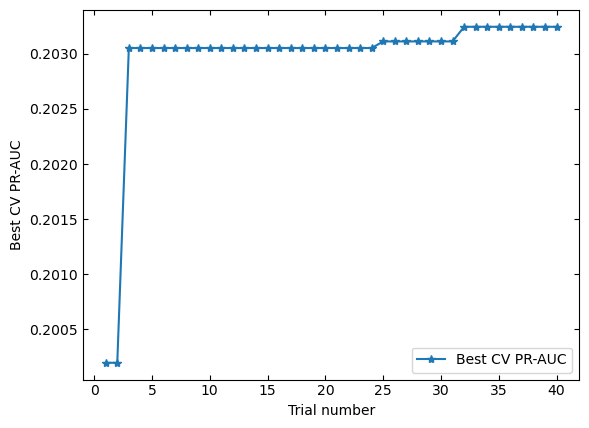

In [24]:
import matplotlib.pyplot as plt

values = []

for i in opt.trials:
    values.append(i.value)

trial_lst = pd.Series(values).cummax().tolist()

plt.figure()
plt.plot(np.arange(1, len(trial_lst)+1), trial_lst, marker="*", label="Best CV PR-AUC")
plt.xlabel("Trial number")
plt.ylabel("Best CV PR-AUC")
plt.grid(False)
plt.tick_params(axis='both', which='major', direction='in', top=True, right=True)
plt.legend(loc = "lower right")
plt.savefig("bayesian_optimisation_convergence_2.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
best_params = opt.best_params

best_config = SGDClassifier(loss="log_loss", learning_rate="constant", max_iter=1000, tol=1e-3, random_state=30,
    eta0=best_params["eta0"], alpha=best_params["alpha"], penalty=best_params["penalty"], class_weight=best_params["class_weight"])

final_pipe = Pipeline([("preprocess", preprocess), ("model", best_config)])
final_pipe.fit(xtrain, ytrain)

validation_proba = final_pipe.predict_proba(xvalidation)[:, 1]
validation_pr_auc = average_precision_score(yvalidation, validation_proba)

print("Validation PR-AUC:", validation_pr_auc)

test_proba = final_pipe.predict_proba(xtest)[:, 1]
test_pr_auc = average_precision_score(ytest, test_proba)

print("Test PR-AUC:", test_pr_auc)

print (best_params)

Validation PR-AUC: 0.21391111600652146
Test PR-AUC: 0.21638918834372084
{'eta0': 0.001507155779414777, 'alpha': 0.005585181495110666, 'penalty': 'l2', 'class_weight': None}


In [26]:
results = []

for j in opt.trials:
    results.append({"Trial": j.number, "eta0": j.params.get("eta0"), "alpha": j.params.get("alpha"), "penalty": j.params.get("penalty"), 
                    "class_weight": j.params.get("class_weight"),"CV_PR-AUC": j.value,
                    "runtime_s": j.duration.total_seconds()})

results = pd.DataFrame(results)
results.to_csv("section_d_results.csv", index=False)
Final_Results = pd.DataFrame([{
    "Best_CV_PR-AUC": opt.best_value,
    "Best_params": str(opt.best_params),
    "Validation_PR-AUC": validation_pr_auc,
    "Test_PR-AUC": test_pr_auc,
    "runtime_s": runtime}])

Final_Results.to_csv("section_d_bayes_final_performance.csv", index=False)